# Trajectory Analysis across models for Suo et. al.

In [1]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import random
from typing import Dict, Tuple, Union

sc.settings.verbose = 3

In [4]:
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.input import InputTrajectories, InputTrajectory
from sctram.generate.real import sc_suo_developmental_complete

2025-06-03 09:26:19.162 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-06-03 09:26:19.168 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

Download the dataset and preliminary subsetting

In [6]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

In [7]:
adata_suo_complete = sc_suo_developmental_complete(dataset_dir=dataset_dir)
display(adata_suo_complete)
adata_suo_complete.obs["LVL0"].value_counts()

2025-06-03 09:26:33.281 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


AnnData object with n_obs × n_vars = 841922 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

LVL0
Haematopoeitic_lineage    561947
Stromal                   209775
Epithelial                 35148
Endothelial                33042
Neuronal_and_Glial          2010
Name: count, dtype: int64

# Scrambling

In [8]:
input_trajectories_path_original = os.path.join(dataset_dir, f"adata_suo_input_haematopoeitic_lineage.pkl")
with open(input_trajectories_path_original, "rb") as _file:
    lit_original = pickle.load(_file)
display(lit_original)

InputTrajectories (trajectories=27, nodes=69, edges=297)

In [49]:
trajectories_to_scramble = [
    "early_b_cells",
    "b_cells",
    "erythroid_megakaryocyte",
    "complete_stem_trajectory",
    "early_stem_trajectory"
]
sorted(trajectories_to_scramble)

['b_cells',
 'complete_stem_trajectory',
 'early_b_cells',
 'early_stem_trajectory',
 'erythroid_megakaryocyte']

In [10]:
def scramble_node_names(
    g: "InputTrajectory",
    amount: float = 0.2,
    exclude_root=False,
    seed: int = 0,
) -> Tuple["InputTrajectory", Dict[str, str], float]:
    """Scramble (swap) node labels in a copy of *G*.

    The edge structure is preserved; only the *names* (labels) attached to
    nodes are shuffled.  The function returns a copy — your original graph stays
    intact.
    """
    if not 0 <= amount <= 1:
        raise ValueError("amount must be between 0 and 1 inclusive")

    rng = random.Random(seed)

    # Work on a copy so we never mutate the caller's graph
    scrambled = g.copy()

    # Identify or validate the root node
    root = None
    if exclude_root:
        roots = [n for n, indeg in g.in_degree() if indeg == 0]
        if not roots:
            raise ValueError(
                "Cannot infer root automatically: graph has no node with in‑degree 0; "
                "disable 'exclude_root' or supply a graph with an identifiable root."
            )
        root = roots[0]

    # All nodes except the root are candidates for swapping
    candidates = [n for n in scrambled.nodes if not (exclude_root and n == root)]
    n_candidates = len(candidates)
    n_to_swap = int((n_candidates) * amount)

    # Ensure an even number so every node gets a partner
    if n_to_swap % 2 == 1:
        n_to_swap -= 1

    # Nothing to do if user asked for ~0 scramble
    if n_to_swap <= 1:
        identity = {n: n for n in scrambled.nodes}
        return scrambled, identity, 1.0

    selected = rng.sample(candidates, n_to_swap)

    # Derangement: rotate the list so every node maps to a *different* node
    rotated = selected[1:] + selected[:1]
    relabel_map = {old: new for old, new in zip(selected, rotated)}

    # Apply relabeling (copy already created)
    scrambled = nx.relabel_nodes(scrambled, relabel_map, copy=True)

    # Build a complete mapping including untouched nodes
    full_mapping = {n: relabel_map.get(n, n) for n in g.nodes}

    unchanged = sum(1 for orig, new in full_mapping.items() if orig == new)
    accuracy = unchanged / len(g)

    return scrambled, full_mapping, accuracy

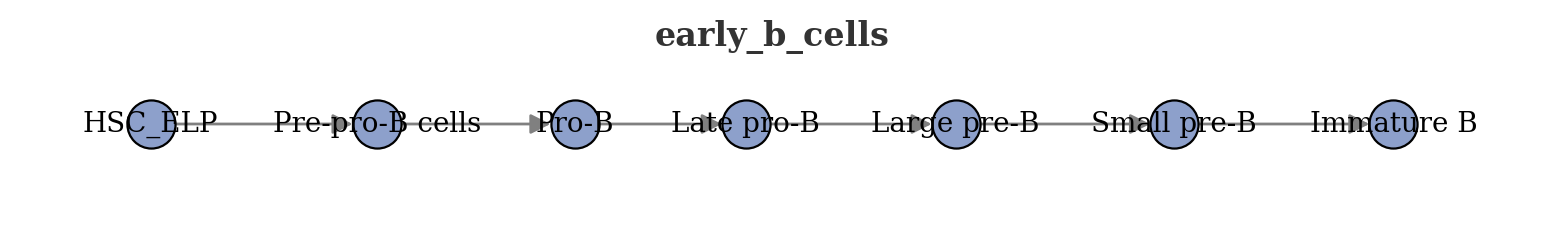

In [11]:
lit_original.get_trajectory("early_b_cells", False).plot_trajectory(figsize=(8,1))

In [12]:
scrambled_trajectories = list()
index = 0
for trajectory in trajectories_to_scramble:
    for seed in range(20):
        for amount in np.linspace(start=0, stop=1, num=40):
            scrambled_trajectory, full_mapping, accuracy = scramble_node_names(
                lit_original.get_trajectory(trajectory, False), 
                amount=amount, 
                seed=seed,
                exclude_root=False
            )
            new_trajectory_name = f"{trajectory}_{index}"
            scrambled_trajectory.graph["trajectories"] = new_trajectory_name
            r = dict(
                index=index,
                trajectory_name = trajectory,
                new_trajectory_name = new_trajectory_name,
                amount=amount,
                seed=seed,
                accuracy = accuracy,
                full_mapping_tuple = tuple(sorted((i, j) for i, j in full_mapping.items())),
                full_mapping_dict = full_mapping,
                scrambled_trajectory = scrambled_trajectory
            )
            index += 1
            scrambled_trajectories.append(r)

In [13]:
df = pd.DataFrame(scrambled_trajectories)
df = df.drop_duplicates(subset=["trajectory_name", "full_mapping_tuple"])
one_per_traj = (
    df[df["accuracy"] == 1]
    .sort_values(["seed", "full_mapping_tuple"])      # <- tie-breaker; adjust if you like
    .drop_duplicates(subset=["trajectory_name"])   # keep first hit
)
rest = df[df["accuracy"] < 1]
df = pd.concat([one_per_traj, rest], ignore_index=True)
df = df.sort_values(["trajectory_name", "accuracy", "amount"]).reset_index(drop=True)
df.shape

(506, 9)

In [14]:
def limit_rows_per_combo(df: pd.DataFrame, n: int, *, random: bool = False, seed: Union[int, None] = None) -> pd.DataFrame:
    if n < 1:
        raise ValueError("n must be at least 1")

    if random:
        # random sampling per group (deterministic when seed is given)
        return (
            df.groupby(["trajectory_name", "accuracy"], group_keys=False)
              .apply(lambda g: g.sample(n=min(n, len(g)), random_state=seed))
              .reset_index(drop=True)
        )

    # deterministic: keep the first `n` rows already ordered in `df`
    mask = (
        df.groupby(["trajectory_name", "accuracy"])
          .cumcount()
          .lt(n)          # True for the first n rows, False afterwards
    )
    return df[mask].reset_index(drop=True)

In [15]:
df_subset = limit_rows_per_combo(df, n=10, seed=0)
df_subset.shape

(265, 9)

In [16]:
lit = InputTrajectories()
for _, trajectory_row in df_subset.iterrows():
    t = trajectory_row["scrambled_trajectory"]
    lit.add_trajectory(t)
lit

InputTrajectories (trajectories=265, nodes=32, edges=2989)

In [17]:
df_subset[df_subset["trajectory_name"] == "early_b_cells"].iloc[-2]["new_trajectory_name"]

'early_b_cells_532'

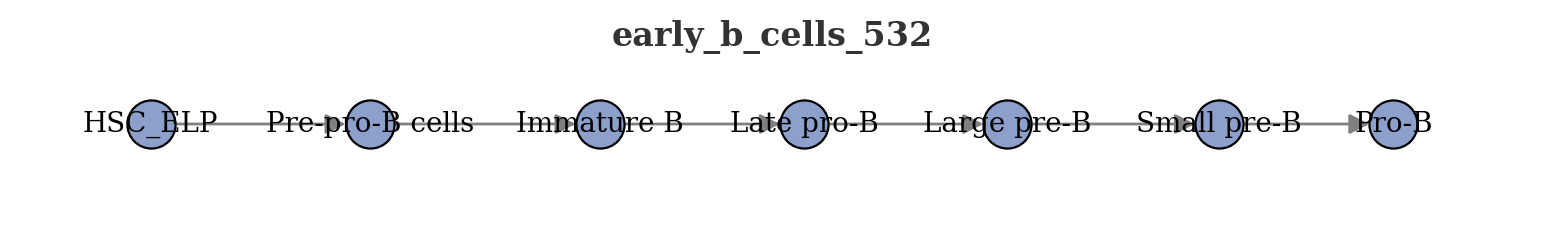

In [18]:
lit.get_trajectory("early_b_cells_532", False).plot_trajectory(figsize=(8,1))

In [19]:
input_trajectories_path_with_df = os.path.join(dataset_dir, f"scrambled_haematopoeitic_lineage_suo_trajectories_with_df.pkl")
with open(input_trajectories_path_with_df, 'wb') as _file:
    pickle.dump((lit, df_subset), _file)

In [20]:
input_trajectories_path = os.path.join(dataset_dir, f"scrambled_haematopoeitic_lineage_suo_trajectories.pkl")
with open(input_trajectories_path, 'wb') as _file:
    pickle.dump(lit, _file)

# Running scTRAM

In [53]:
input_trajectories_path = os.path.join(dataset_dir, f"scrambled_haematopoeitic_lineage_suo_trajectories.pkl")
with open(input_trajectories_path, "rb") as _file:
    lit = pickle.load(_file)
display(lit)

InputTrajectories (trajectories=265, nodes=32, edges=2989)

In [54]:
adata_suo_complete.obsm.keys()

KeysView(AxisArrays with keys: Unintegrated, X_pca, harmony, invae, scanvi, scvi, tardis_1, tardis_2)

In [55]:
override = False

count = 0
lineage = "Haematopoeitic_lineage"

for use_rep in ["scanvi", "tardis_2", "X_pca"]:
    
    lineage_part = lineage.replace("_lineage", "").lower()

    for trajectory in sorted(lit.graph["trajectories"]):
    
        if use_rep == "Unintegrated":
            continue

        output_file = os.path.join(dataset_dir, f"metric_sctram_suo_scrambling_{lineage_part}_{use_rep}_{trajectory}.pickle")
        log_file = os.path.join(logs_directory, f"slurm_out_metric_sctram_suo_scrambling_{lineage_part}_{use_rep}_{trajectory}.log")

        if override or not os.path.exists(output_file):
            try:
                slurm_script = f"""#!/bin/bash
#SBATCH -J sctram_calc_{count+1}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 32
#SBATCH --mem=293G
#SBATCH --nice=0
#SBATCH -t 11:50:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, 'suo_sctram.py')} --lineage "{lineage}" --use_rep "{use_rep}" --trajectory_object_path "{input_trajectories_path}" --trajectory "{trajectory}"
    """
                script_name = os.path.join(logs_directory, f"slurm_job_metric_sctram_suo_scrambling_{lineage_part}_{use_rep}_{trajectory}.sh")
                with open(script_name, "w") as f:
                    f.write(slurm_script)

                print(f"Submitted job {count+1!r} of {lineage!r} with {use_rep!r} of trajectory {trajectory!r}")
                subprocess.run(["sbatch", script_name])
                count += 1
            finally:
                os.remove(script_name)
        else:
            print(f"Data exists for {lineage!r} with {use_rep!r} of trajectory {trajectory!r}")
    # if count > 32:
    #     break

print(f" - Number of jobs submitted: {count}")

Submitted job 1 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1008'
Submitted batch job 36825451
Submitted job 2 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1015'
Submitted batch job 36825452
Submitted job 3 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1022'
Submitted batch job 36825453
Submitted job 4 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1029'
Submitted batch job 36825454
Submitted job 5 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1036'
Submitted batch job 36825455
Submitted job 6 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1048'
Submitted batch job 36825456
Submitted job 7 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1055'
Submitted batch job 36825457
Submitted job 8 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 'b_cells_1062'
Submitted batch job 36825458
Submitted job 9 of 'Haematopoeitic_lineage' with 'scanvi' of trajectory 

In [56]:
def smart_subsample(adata, group_key="LVL3", max_cells_per_group=500, random_state=0):
    """
    Subsample overrepresented groups to 'max_cells_per_group' cells,
    retain all cells from underrepresented groups.
    """
    np.random.seed(random_state)
    groups = adata.obs[group_key]
    indices_to_keep = []

    for group in groups.unique():
        group_indices = adata.obs.index[groups == group].tolist()
        if len(group_indices) > max_cells_per_group:
            selected = np.random.choice(group_indices, max_cells_per_group, replace=False)
            indices_to_keep.extend(selected)
        else:
            indices_to_keep.extend(group_indices)

    return adata[indices_to_keep].copy()

In [57]:
adata_suo_subset = adata_suo_complete[adata_suo_complete.obs["LVL0"] == "Haematopoeitic_lineage"]
adata_suo_subset

View of AnnData object with n_obs × n_vars = 561947 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [58]:
smart_subsample(adata_suo_complete, group_key="LVL3", max_cells_per_group=1500)

AnnData object with n_obs × n_vars = 115770 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [60]:
1

1